In [2]:
import numpy as np  # Import NumPy library

# Create a Perceptron class
class Perceptron:
    # Constructor to initialize weights and bias
    def __init__(self, weights, bias):
        self.weights = np.array(weights)
        self.bias = bias

    # Predict the output for a given input
    def predict(self, inputs):
        # Compute weighted sum: (x1*w1 + x2*w2 + bias)
        summation = np.dot(inputs, self.weights) + self.bias

        # Apply step activation function
        # Return 1 if weighted sum >= 0, otherwise return 0
        return 1 if summation >= 0 else 0


# Truth table inputs
inputs = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# Create an AND gate perceptron by assigning weights and bias
and_gate = Perceptron(weights=[1, 1], bias=-1.5)

print("AND Gate")

# Process each input combination
for x in inputs:
    # Predict and display the output
    print(f"{x} -> {and_gate.predict(x)}")

AND Gate
[0 0] -> 0
[0 1] -> 0
[1 0] -> 0
[1 1] -> 1


In [4]:
# OR Gate using Perceptron

class Perceptron:
    def __init__(self):
        # Initialize weights and bias
        self.weights = [1, 1]
        self.bias = -0.5

    # Activation Function (Step Function)
    def activation(self, x):
        if x >= 0:
            return 1
        else:
            return 0

    # Prediction Function
    def predict(self, inputs):
        total = (inputs[0] * self.weights[0]) + \
                (inputs[1] * self.weights[1]) + self.bias
        return self.activation(total)


# Create Perceptron Object
p = Perceptron()

# OR Gate Inputs
data = [
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
]

print("X1 X2 Output")

for d in data:
    output = p.predict(d)
    print(d[0], " ", d[1], "   ", output)

X1 X2 Output
0   0     0
0   1     1
1   0     1
1   1     1


In [5]:
# NAND Gate using Perceptron

class Perceptron:
    def __init__(self):
        # Initialize weights and bias
        self.weights = [-1, -1]
        self.bias = 1.5

    # Activation Function (Step Function)
    def activation(self, x):
        if x >= 0:
            return 1
        else:
            return 0

    # Prediction Function
    def predict(self, inputs):
        total = (inputs[0] * self.weights[0]) + \
                (inputs[1] * self.weights[1]) + self.bias
        return self.activation(total)


# Create Perceptron Object
p = Perceptron()

# NAND Gate Inputs
data = [
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
]

print("X1 X2 Output")

for d in data:
    output = p.predict(d)
    print(d[0], " ", d[1], "   ", output)

X1 X2 Output
0   0     1
0   1     1
1   0     1
1   1     0


In [9]:
# Perceptron Weight Updation (One Epoch)

learning_rate = 0.2

# Initial weights and bias
w1 = 0.3
w2 = 0.1
bias = 0

# AND Gate Training Data
training_data = [
    [0, 0, 0],
    [0, 1, 0],
    [1, 0, 0],
    [1, 1, 1]
]

# Step Activation Function
def step(x):
    if x >= 0:
        return 1
    else:
        return 0

print("Initial Weights:", w1, w2)
print("Initial Bias:", bias)

print("\nTraining for One Epoch\n")

print("X1 X2 Target Net Output Error Updated_W1 Updated_W2 Updated_Bias")

for data in training_data:

    x1 = data[0]
    x2 = data[1]
    target = data[2]

    # Net Input
    net = (x1 * w1) + (x2 * w2) + bias

    # Output
    output = step(net)

    # Error
    error = target - output

    # Weight Update
    w1 = w1 + learning_rate * error * x1
    w2 = w2 + learning_rate * error * x2

    # Bias Update
    bias = bias + learning_rate * error

    print(x1, x2, target,
          round(net,2),
          output,
          error,
          round(w1,2),
          round(w2,2),
          round(bias,2))

print("\nFinal Weights =", round(w1,2), round(w2,2))
print("Final Bias =", round(bias,2))

Initial Weights: 0.3 0.1
Initial Bias: 0

Training for One Epoch

X1 X2 Target Net Output Error Updated_W1 Updated_W2 Updated_Bias
0 0 0 0.0 1 -1 0.3 0.1 -0.2
0 1 0 -0.1 0 0 0.3 0.1 -0.2
1 0 0 0.1 1 -1 0.1 0.1 -0.4
1 1 1 -0.2 0 1 0.3 0.3 -0.2

Final Weights = 0.3 0.3
Final Bias = -0.2


X1 X2 Output
0   0     1
0   1     0
1   0     0
1   1     0


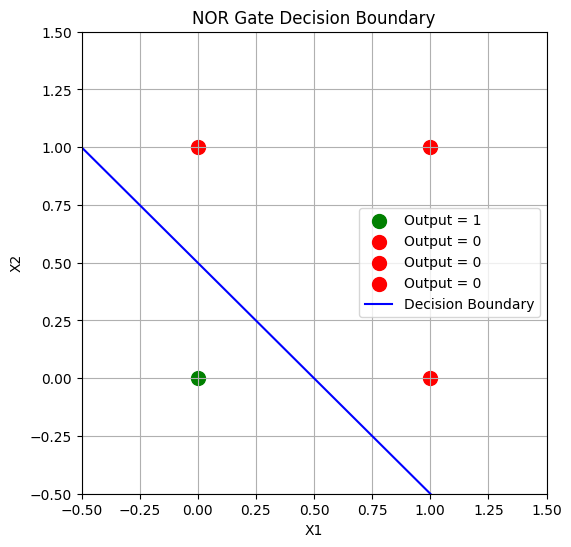

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Perceptron Class
class Perceptron:
    def __init__(self):
        # Weights and Bias for NOR Gate
        self.weights = [-1, -1]
        self.bias = 0.5

    # Step Activation Function
    def activation(self, x):
        if x >= 0:
            return 1
        else:
            return 0

    # Prediction Function
    def predict(self, inputs):
        total = (inputs[0] * self.weights[0]) + \
                (inputs[1] * self.weights[1]) + self.bias
        return self.activation(total)


# Create Perceptron
p = Perceptron()

# NOR Gate Inputs
data = [
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
]

print("X1 X2 Output")

for d in data:
    output = p.predict(d)
    print(d[0], " ", d[1], "   ", output)


# -----------------------------
# Decision Boundary
# -----------------------------

x = np.linspace(-0.5, 1.5, 100)

# Equation:
# -x1 - x2 + 0.5 = 0
y = 0.5 - x

plt.figure(figsize=(6,6))

# Plot input points
for d in data:
    if p.predict(d) == 1:
        plt.scatter(d[0], d[1], color='green', s=100, label='Output = 1')
    else:
        plt.scatter(d[0], d[1], color='red', s=100, label='Output = 0')

# Plot decision boundary
plt.plot(x, y, 'b-', label='Decision Boundary')

plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)

plt.xlabel("X1")
plt.ylabel("X2")
plt.title("NOR Gate Decision Boundary")

plt.grid(True)
plt.legend()
plt.show()

In [7]:
# Verify AND, OR and NAND Gates using Perceptron

class Perceptron:

    def __init__(self, weights, bias):
        self.weights = weights
        self.bias = bias

    def activation(self, x):
        if x >= 0:
            return 1
        else:
            return 0

    def predict(self, inputs):
        total = (inputs[0] * self.weights[0]) + \
                (inputs[1] * self.weights[1]) + self.bias
        return self.activation(total)


# Input Data
inputs = [
    [0,0],
    [0,1],
    [1,0],
    [1,1]
]

# Gate Details
gates = {
    "AND": ([0.3,0.3], -0.5),
    "OR": ([1,1], -0.5),
    "NAND": ([-1,-1], 1.5)
}

# Verify Outputs
for gate in gates:

    weights, bias = gates[gate]
    p = Perceptron(weights, bias)

    print("\n",gate,"Gate")
    print("X1 X2 Output")

    for x in inputs:
        print(x[0], x[1], " ", p.predict(x))


 AND Gate
X1 X2 Output
0 0   0
0 1   0
1 0   0
1 1   1

 OR Gate
X1 X2 Output
0 0   0
0 1   1
1 0   1
1 1   1

 NAND Gate
X1 X2 Output
0 0   1
0 1   1
1 0   1
1 1   0


In [8]:
import math

# Perceptron Class
class Perceptron:

    def __init__(self, weights, bias):
        self.weights = weights
        self.bias = bias

    # Sigmoid Activation
    def sigmoid(self, x):
        return 1 / (1 + math.exp(-x))

    # ReLU Activation
    def relu(self, x):
        return max(0, x)

    # Calculate Net Input
    def net_input(self, inputs):
        return (inputs[0] * self.weights[0]) + \
               (inputs[1] * self.weights[1]) + self.bias


# OR Gate Weights
weights = [1, 1]
bias = -0.5

p = Perceptron(weights, bias)

# Input Data
inputs = [
    [0,0],
    [0,1],
    [1,0],
    [1,1]
]

print("X1 X2  Net   Sigmoid   ReLU")

for x in inputs:

    net = p.net_input(x)

    s = p.sigmoid(net)

    r = p.relu(net)

    print(x[0], x[1], round(net,2), round(s,3), round(r,3))

X1 X2  Net   Sigmoid   ReLU
0 0 -0.5 0.378 0
0 1 0.5 0.622 0.5
1 0 0.5 0.622 0.5
1 1 1.5 0.818 1.5


In [10]:
# Learning Rate Comparison using Perceptron

training_data = [
    [0, 0, 0],
    [0, 1, 0],
    [1, 0, 0],
    [1, 1, 1]
]

learning_rates = [0.1, 0.5, 1.0]

for lr in learning_rates:

    w1 = 0
    w2 = 0
    bias = 0

    epoch = 0

    while True:

        error_count = 0

        for x1, x2, target in training_data:

            net = x1*w1 + x2*w2 + bias

            if net >= 0:
                output = 1
            else:
                output = 0

            error = target - output

            if error != 0:

                w1 = w1 + lr * error * x1
                w2 = w2 + lr * error * x2
                bias = bias + lr * error

                error_count += 1

        epoch += 1

        if error_count == 0:
            break

    # Accuracy
    correct = 0

    for x1, x2, target in training_data:

        net = x1*w1 + x2*w2 + bias

        if net >= 0:
            output = 1
        else:
            output = 0

        if output == target:
            correct += 1

    accuracy = (correct / len(training_data)) * 100

    print("-----------------------------------")
    print("Learning Rate =", lr)
    print("Epochs =", epoch)
    print("Final Weights =", round(w1,2), round(w2,2))
    print("Final Bias =", round(bias,2))
    print("Accuracy =", accuracy,"%")


-----------------------------------
Learning Rate = 0.1
Epochs = 4
Final Weights = 0.2 0.1
Final Bias = -0.2
Accuracy = 100.0 %
-----------------------------------
Learning Rate = 0.5
Epochs = 6
Final Weights = 1.0 0.5
Final Bias = -1.5
Accuracy = 100.0 %
-----------------------------------
Learning Rate = 1.0
Epochs = 6
Final Weights = 2.0 1.0
Final Bias = -3.0
Accuracy = 100.0 %


In [11]:
# XOR Gate using Single Perceptron

class Perceptron:

    def __init__(self):
        # Example weights and bias
        self.weights = [1, 1]
        self.bias = -0.5

    # Step Activation Function
    def activation(self, x):
        if x >= 0:
            return 1
        else:
            return 0

    # Prediction Function
    def predict(self, inputs):
        net = (inputs[0] * self.weights[0]) + \
              (inputs[1] * self.weights[1]) + self.bias

        return self.activation(net)


# Create Perceptron
p = Perceptron()

# XOR Inputs
data = [
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
]

print("X1 X2 Predicted Output")

for d in data:
    print(d[0], d[1], "      ", p.predict(d))

X1 X2 Predicted Output
0 0        0
0 1        1
1 0        1
1 1        1
